# Homework 3: Convolutional Neural Network

In this homework we will create a Convolutional Neural Network (CNN) from scratch in
Python. We will implement things such as a Reshape Layer, the Binary Cross Entropy Loss,
and the Sigmoid Activation, etc. Finally, we'll use all these objects to make a neural
network capable of classifying handwritten digits from the MNIST dataset. Before
beginning, make sure you’re comfortable calculating cross correlation and convolution
from a given input and kernel. See the next 2 slides.

Be sure to download the starter code files. You’re welcome to transfer the code to a
jupyter notebook

#### Cross-Correlation
1: Given the following input and kernel, what is the cross correlation (output)?

(1 * 1) + (6 * 2) + (5(−1)) + (3 * 0)=1 + 12 − 5 + 0 = 8

(6 * 1) + (2 * 2) + (3(−1)) + (1 * 0)= 6 + 4 − 3 + 0 = 7

(5 * 1) + (3 * 2) + (7(−1)) + (0 * 0) = 5 + 6 − 7 + 0 = 4

(3 × 1) + (1 × 2) + (0(−1)) + (4 * 0) = 3 + 2 + 0 + 0 = 5

Final Output: [[8, 7],[4, 5]]

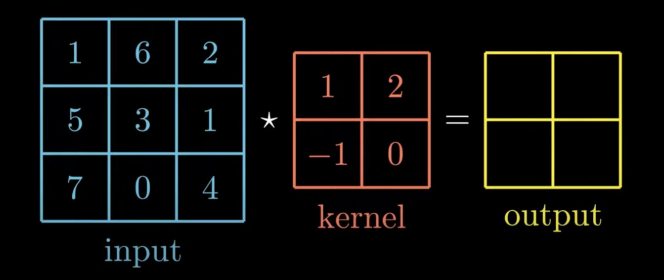

In [5]:
display.Image("question1.png")

2: Using the given input and kernel, what is the convolution (output)? Hint: Rotate the kernel 180.

Convoluation Kernel: [[0, -1], [2, 1]]

(1 * 0) + (6(-1)) + (5 * 2) + (3 * 1) = 0 - 6 + 10 + 3 = 7

(6 * 0) + (2(-1)) + (3 * 2) + (1 * 1) = 0 - 2 + 6 + 1 = 5

(5 * 0) + (3(-1)) + (7 * 2) + (0 * 1) = 0 - 3 + 14 + 0 = 11

(3 * 0) + (1(-1)) + (0 * 2) + (4 * 1) = 0 - 1 + 0 + 4 = 3

Final Output: [[7, 5], [11, 3]]

#### Implementing Forward

3: You should have the following started code in the convolutional.py file. Please
implement the forward method here or in a jupyter notebook if you transferred the
code over.

#### Implementing Backward

4: You should have the following started code in the convolutional.py file. Please
implement the backward method here or in a jupyter notebook if you transferred
the code over

Implementing Reshape

5: The output of the convolutional layer is 3D block, so we'll need to reshape this into a column vector before passing into our final dense layer for classification. You can find the starter code in reshape.py, or you can transfer the next slide into your notebook

#### Implementing Dense Layer

6: Let's implement our dense layer. The started code is located in dense.py This should be similar to previous homeworks when you learned about neural networks.

#### Implementing Binary Cross Entropy Loss
7: Why is binary cross entropy loss a good choice here?

The homework mentions implementing a Sigmoid activation function, where Binary cross entropy is specifically designed to work with sigmoid outputs. Binary cross entropy is the standard loss function for binary classfication tasks. It directly measures the log-likelihood of the predicted probabilities


Copied and Pasted minst_conv.py file into this notebook cell (below):

In [18]:
import numpy as np
from keras.datasets import mnist
# Removed np_utils import - we'll implement to_categorical manually

from dense import Dense
from convolutional import Convolutional
from reshape import Reshape
from activations import Tanh, Sigmoid
from losses import binary_cross_entropy, binary_cross_entropy_prime

def to_categorical(y, num_classes=None):
    """Convert class vector to binary class matrix (one-hot encoding)"""
    y = np.array(y, dtype='int')
    input_shape = y.shape
    if input_shape and input_shape[-1] == 1 and len(input_shape) > 1:
        input_shape = tuple(input_shape[:-1])
    y = y.ravel()
    if not num_classes:
        num_classes = np.max(y) + 1
    n = y.shape[0]
    categorical = np.zeros((n, num_classes), dtype=np.float32)
    categorical[np.arange(n), y] = 1
    output_shape = input_shape + (num_classes,)
    categorical = np.reshape(categorical, output_shape)
    return categorical

def preprocess_data(x, y, limit):
    ''' 
    Will limit our data since using the whole thing will take forever on a cpu especially since we're
    implementing this from scratch.
    '''
    zero_index = np.where(y == 0)[0][:limit]
    one_index = np.where(y == 1)[0][:limit]
    all_indices = np.hstack((zero_index, one_index))
    all_indices = np.random.permutation(all_indices)
    x, y = x[all_indices], y[all_indices]
    x = x.reshape(len(x), 1, 28, 28)
    x = x.astype("float32") / 255
    y = to_categorical(y)
    y = y.reshape(len(y), 2, 1)
    return x, y

# load MNIST from server, limit to 100 images per class since we're not training on GPU
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, y_train = preprocess_data(x_train, y_train, 100)
x_test, y_test = preprocess_data(x_test, y_test, 100)

# TODO: Add our layers and the flow of input into this list. 
# Network architecture: Conv → Sigmoid → Reshape → Dense → Sigmoid
# Input: (1, 28, 28) - single channel 28x28 image
# Conv: 3x3 kernel, 1 output channel -> output: (1, 26, 26)
# Reshape: (1, 26, 26) -> (676, 1) column vector
# Dense: 676 inputs -> 1 output (binary classification)
network = [
    Convolutional(input_shape=(1, 28, 28), kernel_size=3, depth=1),  # Conv layer
    Sigmoid(),                                                         # Activation
    Reshape(input_shape=(1, 26, 26), output_shape=(676, 1)),         # Reshape to column vector
    Dense(input_size=676, output_size=1),                             # Dense layer
    Sigmoid()                                                          # Final activation
]

epochs = 10
learning_rate = 0.1

# train
for e in range(epochs):
    error = 0
    for x, y in zip(x_train, y_train):
        # forward
        output = x
        for layer in network:
            output = layer.forward(output)

        # TODO: update our error
        # Calculate error using binary cross entropy
        # For binary classification, we only need the positive class (index 1)
        y_binary = y[1, 0]  # Extract the positive class label
        output_binary = output[0, 0]  # Extract the sigmoid output
        
        error += binary_cross_entropy(y_binary, output_binary)

        # TODO: perform back prop
        # Perform backpropagation
        # Create gradient with same shape as output
        gradient = np.zeros_like(output)
        gradient[0, 0] = binary_cross_entropy_prime(y_binary, output_binary)
        for layer in reversed(network):
            gradient = layer.backward(gradient, learning_rate) 

    error /= len(x_train)
    print(f"{e + 1}/{epochs}, error={error}")

# TODO: run the test data through and print out your predictions
print("\nTesting the network:")
correct = 0
total = 0

for x, y in zip(x_test, y_test):
    # Forward pass
    output = x
    for layer in network:
        output = layer.forward(output)
    
    # Get prediction (0 or 1)
    prediction = 1 if output[0, 0] > 0.5 else 0
    true_label = 1 if y[1, 0] > 0.5 else 0  # y is one-hot encoded
    
    if prediction == true_label:
        correct += 1
    total += 1
    
    print(f"Predicted: {prediction}, True: {true_label}, Confidence: {output[0, 0]:.3f}")

accuracy = correct / total
print(f"\nTest Accuracy: {accuracy:.3f} ({correct}/{total})")


1/10, error=0.22359098107364492
2/10, error=0.004758035612872474
3/10, error=0.003402139986593353
4/10, error=0.0025315150277595093
5/10, error=0.001986151263767849
6/10, error=0.001607798337585014
7/10, error=0.0013535242202226396
8/10, error=0.0011764168193270543
9/10, error=0.0010463765944683139
10/10, error=0.0009464277422941106

Testing the network:
Predicted: 0, True: 0, Confidence: 0.002
Predicted: 1, True: 1, Confidence: 1.000
Predicted: 1, True: 1, Confidence: 1.000
Predicted: 1, True: 1, Confidence: 1.000
Predicted: 0, True: 0, Confidence: 0.001
Predicted: 0, True: 0, Confidence: 0.000
Predicted: 1, True: 1, Confidence: 1.000
Predicted: 0, True: 0, Confidence: 0.000
Predicted: 1, True: 1, Confidence: 1.000
Predicted: 1, True: 1, Confidence: 1.000
Predicted: 1, True: 1, Confidence: 1.000
Predicted: 0, True: 0, Confidence: 0.011
Predicted: 0, True: 0, Confidence: 0.000
Predicted: 1, True: 1, Confidence: 1.000
Predicted: 0, True: 0, Confidence: 0.001
Predicted: 0, True: 0, Confi

#### Conclusion:

The loss or binary cross entropy is steadily decreasing, indicating that the tiny model successfully learned to classify digits 0 vs 1. The confidence near 0 or 1 confirm the network converged properly.